# Detection Notebook
This notebook is for exploring the feature extraction, training and inference for the object detectors.



In [1]:
# imports

import os, json, shutil, random, math
from pathlib import Path
from typing import List, Tuple, Dict, Set
import numpy as np
import cv2
import torch
from tqdm import tqdm
import yaml

# Ultralytics (YOLOv8/YOLOv10 unified API)
from ultralytics import YOLO

SEED = 42

In [2]:
DATA_ROOT = Path("Data/training_set").resolve()

IM_DIR   = DATA_ROOT / "images"
LBL_DIR  = DATA_ROOT / "slz_out" / "det_obb" / "labels_yolo_obb"
COCO_JSON= DATA_ROOT / "slz_out" / "det_obb" / "slz_obb_all.json"
SPLIT_ROOT = (DATA_ROOT / "slz_out" / "det_obb" / "splits_yolo_obb").resolve()

assert IM_DIR.exists(),   f"Missing images at {IM_DIR}"
assert LBL_DIR.exists(),  f"Missing YOLO-OBB labels at {LBL_DIR}"
assert COCO_JSON.exists(),f"Missing COCO-like JSON at {COCO_JSON}"

print("Images dir:", IM_DIR)
print("Labels dir:", LBL_DIR)
print("COCO JSON :", COCO_JSON)


Images dir: E:\Documents\updated uni work\KU PhD\Research\Projects\SafeLanding\UAV-Seg2Det-SafeLanding\Data\training_set\images
Labels dir: E:\Documents\updated uni work\KU PhD\Research\Projects\SafeLanding\UAV-Seg2Det-SafeLanding\Data\training_set\slz_out\det_obb\labels_yolo_obb
COCO JSON : E:\Documents\updated uni work\KU PhD\Research\Projects\SafeLanding\UAV-Seg2Det-SafeLanding\Data\training_set\slz_out\det_obb\slz_obb_all.json


In [3]:
with open(COCO_JSON, "r") as f:
    coco = json.load(f)

# id -> name, then sorted by id to ensure correct order
id_to_name = {c["id"]: c["name"] for c in coco["categories"]}
names = [id_to_name[i] for i in sorted(id_to_name)]
names

['slz_l2', 'slz_l3']

## Create the data split

In [4]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def find_image_label_pairs(im_dir: Path, lbl_dir: Path) -> List[Tuple[Path, Path]]:
    pairs = []
    for p in sorted(im_dir.iterdir()):
        if p.suffix.lower() in IMG_EXTS:
            lbl = lbl_dir / f"{p.stem}.txt"
            if lbl.exists():
                pairs.append((p, lbl))
    return pairs

def classes_in_label_file(lbl_path: Path) -> Set[int]:
    s = lbl_path.read_text(encoding="utf-8", errors="ignore").strip().splitlines()
    out = set()
    for line in s:
        line = line.strip()
        if not line:
            continue  # empty file allowed (negative image)
        parts = line.split()
        cls = int(float(parts[0]))  # be robust to "0.0"
        out.add(cls)
    return out

pairs = find_image_label_pairs(IM_DIR, LBL_DIR)
print(f"Found {len(pairs)} image/label pairs")

# Build lightweight index
per_img_classes: Dict[str, Set[int]] = {}
for img, lbl in tqdm(pairs, total=len(pairs), desc="Parsing labels"):
    per_img_classes[img.stem] = classes_in_label_file(lbl)

# Quick distribution
from collections import Counter
cnt = Counter()
empty = 0
for s in per_img_classes.values():
    if s:
        for c in s: cnt[c] += 1
    else:
        empty += 1

print("Per-class image counts:", {names[k]: v for k,v in cnt.items()})
print("Images with NO objects :", empty)


Found 400 image/label pairs


Parsing labels: 100%|██████████| 400/400 [00:00<00:00, 3273.67it/s]

Per-class image counts: {'slz_l2': 393, 'slz_l3': 173}
Images with NO objects : 6


In [6]:
# 4) Split into train/val/test (reproducible, stratified)
g = torch.Generator().manual_seed(SEED)

img_paths = [p[0] for p in pairs]   # from earlier
stems     = [p.stem for p in img_paths]

def dominant_tag(stem: str) -> str:
    s = per_img_classes[stem]  # from earlier
    if not s:
        return "none"
    return names[max(s)]  # prefer higher level if both present (e.g., slz_l3 over slz_l2)

# bucket images by dominant tag
from collections import defaultdict
buckets = defaultdict(list)
for p in img_paths:
    buckets[dominant_tag(p.stem)].append(p)

ratios = (0.8, 0.1, 0.1)  # train/val/test
train_imgs, val_imgs, test_imgs = [], [], []

for tag, arr in buckets.items():
    n = len(arr)
    if n == 0:
        continue
    # shuffle with torch RNG
    idx = torch.randperm(n, generator=g).tolist()
    arr = [arr[i] for i in idx]

    n_train = int(round(n * ratios[0]))
    n_val   = int(round(n * ratios[1]))
    if n_train + n_val > n:
        n_val = max(0, n - n_train)
    n_test = n - n_train - n_val

    train_imgs += arr[:n_train]
    val_imgs   += arr[n_train:n_train+n_val]
    test_imgs  += arr[n_train+n_val:]

# final shuffle of each split (optional)
train_imgs = [train_imgs[i] for i in torch.randperm(len(train_imgs), generator=g).tolist()]
val_imgs   = [val_imgs[i]   for i in torch.randperm(len(val_imgs),   generator=g).tolist()]
test_imgs  = [test_imgs[i]  for i in torch.randperm(len(test_imgs),  generator=g).tolist()]

def to_labels(imgs: list[Path]) -> list[Path]:
    return [LBL_DIR / f"{p.stem}.txt" for p in imgs]

train_lbls = to_labels(train_imgs)
val_lbls   = to_labels(val_imgs)
test_lbls  = to_labels(test_imgs)

print(len(train_imgs), len(val_imgs), len(test_imgs))

# quick split stats (optional)
def split_stats(imgs):
    from collections import defaultdict
    tally = defaultdict(int)
    none = 0
    for p in imgs:
        s = per_img_classes[p.stem]
        if not s: none += 1
        else:
            for c in s: tally[c]+=1
    return {"none": none, **{names[k]: v for k,v in tally.items()}}

print("Train:", split_stats(train_imgs))
print("Val  :", split_stats(val_imgs))
print("Test :", split_stats(test_imgs))


320 40 40
Train: {'none': 5, 'slz_l2': 314, 'slz_l3': 138}
Val  : {'none': 1, 'slz_l2': 39, 'slz_l3': 17}
Test : {'none': 0, 'slz_l2': 40, 'slz_l3': 18}


In [7]:
for sub in ["images/train","images/val","images/test","labels/train","labels/val","labels/test"]:
    (SPLIT_ROOT / sub).mkdir(parents=True, exist_ok=True)

def link_or_copy(src: Path, dst: Path):
    try:
        if dst.exists(): dst.unlink()
        os.symlink(src, dst)  # may fail on Windows without admin
    except Exception:
        shutil.copy2(src, dst)

def materialize(imgs: List[Path], lbls: List[Path], split: str):
    im_out = SPLIT_ROOT / "images" / split
    lb_out = SPLIT_ROOT / "labels" / split
    for im, lb in tqdm(list(zip(imgs, lbls)), total=len(imgs), desc=f"Writing {split}"):
        link_or_copy(im, im_out / im.name)
        link_or_copy(lb, lb_out / lb.name)

materialize(train_imgs, train_lbls, "train")
materialize(val_imgs,   val_lbls,   "val")
materialize(test_imgs,  test_lbls,  "test")

print("Split root:", SPLIT_ROOT)


Writing test: 100%|██████████| 40/40 [00:00<00:00, 43.14it/s]

Split root: E:\Documents\updated uni work\KU PhD\Research\Projects\SafeLanding\UAV-Seg2Det-SafeLanding\Data\training_set\slz_out\det_obb\splits_yolo_obb


In [9]:
DATA_YAML = SPLIT_ROOT / "slz_obb_dataset.yaml"

data = {
    "path": SPLIT_ROOT.as_posix(),
    "train": "images/train", "val": "images/val", "test": "images/test",
    "names": names, "task": "obb", "nc": len(names)
}
DATA_YAML.write_text(yaml.safe_dump(data, sort_keys=False), encoding="utf-8")

print(DATA_YAML.read_text())


path: E:/Documents/updated uni work/KU PhD/Research/Projects/SafeLanding/UAV-Seg2Det-SafeLanding/Data/training_set/slz_out/det_obb/splits_yolo_obb
train: images/train
val: images/val
test: images/test
names:
- slz_l2
- slz_l3
task: obb
nc: 2



## Load Data Split

In [8]:
# Paths — point straight to the existing YAML you already wrote
DATA_YAML = Path("Data/training_set/slz_out/det_obb/splits_yolo_obb/slz_obb_dataset.yaml").resolve()
print(DATA_YAML, DATA_YAML.exists())


E:\Documents\updated uni work\KU PhD\Research\Projects\SafeLanding\UAV-Seg2Det-SafeLanding\Data\training_set\slz_out\det_obb\splits_yolo_obb\slz_obb_dataset.yaml True


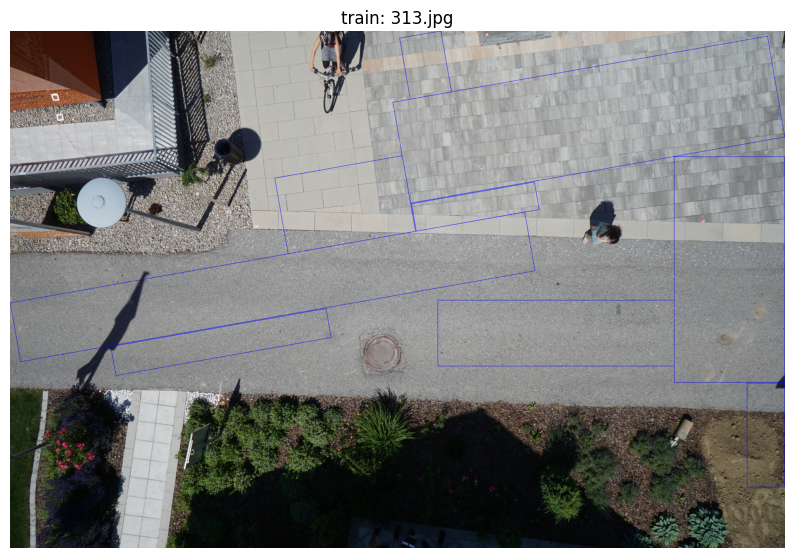

In [5]:
# Standalone sample viewer (no re-splitting needed)
from pathlib import Path
import random, cv2, numpy as np
from matplotlib import pyplot as plt

SPLIT_ROOT = Path("Data/training_set/slz_out/det_obb/splits_yolo_obb").resolve()
SPLIT = "train"   # or "val" / "test"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def draw_obb_on_image(img_bgr: np.ndarray, label_path: Path, thickness=2):
    H, W = img_bgr.shape[:2]
    if not label_path.exists():
        return img_bgr

    lines = label_path.read_text(encoding="utf-8", errors="ignore").strip().splitlines()
    for line in lines:
        if not line.strip():
            continue
        vals = [float(x) for x in line.split()]
        cls  = int(round(vals[0]))
        ptsn = np.array(vals[1:], dtype=np.float32).reshape(4,2)  # normalized
        pts  = ptsn.copy()
        pts[:,0] *= W; pts[:,1] *= H
        pts  = pts.astype(np.int32)

        # class colors (BGR): 0 -> blue, 1 -> green; fallback = yellow if other class ids occur
        color = (255, 0, 0) if cls == 0 else (0, 255, 0) if cls == 1 else (0, 255, 255)
        cv2.polylines(img_bgr, [pts], isClosed=True, color=color, thickness=thickness)

    return img_bgr

# pick a random image from the chosen split
img_dir = SPLIT_ROOT / "images" / SPLIT
lbl_dir = SPLIT_ROOT / "labels" / SPLIT
candidates = [p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS]
assert candidates, f"No images found in {img_dir}"
im_path = random.choice(candidates)
lb_path = lbl_dir / f"{im_path.stem}.txt"

img = cv2.imread(str(im_path))
overlay = draw_obb_on_image(img.copy(), lb_path)

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"{SPLIT}: {im_path.name}")
plt.axis('off')
plt.show()


## Train

In [10]:
model_name = "yolov8n-obb.pt"  # quick baseline; try 'yolov8m-obb.pt' for higher accuracy

model = YOLO(model_name)

# Tip: imgsz=1280 is a good starting point for your 6000px images.
#      Use batch=-1 for auto-batch; adjust epochs as needed.
results = model.train(
    data=str(DATA_YAML),
    imgsz=1280,
    epochs=100,
    batch=-1,
    device=0,
    workers=8,
    optimizer="AdamW",
    cos_lr=True,
    warmup_epochs=3,
    seed=SEED,
    project="slz_obb",
    name="yolov8n_baseline",
    verbose=True,
    # Augmentations (reasonable for OBB)
    degrees=10.0,  # small random rotation
    perspective=0.0,
    shear=0.0,
    mosaic=0.15,
    mixup=0.05
)


Ultralytics 8.3.226  Python-3.9.18 torch-2.0.1 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=E:\Documents\updated uni work\KU PhD\Research\Projects\SafeLanding\UAV-Seg2Det-SafeLanding\Data\training_set\slz_out\det_obb\splits_yolo_obb\slz_obb_dataset.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolov8n-obb.pt, momentum=0.937, mosaic=0.15, multi_scale=False,

In [10]:
RUN_DIR = Path("slz_obb/yolov8n_baseline2")  # <- adjust if different
CKPT = RUN_DIR / "weights" / "best.pt"

m = YOLO(str(CKPT))
print("model names:", m.names)            # e.g. ['slz_l2'] if 1-class
print("model nc   :", getattr(m.model, "nc", None))

ck = torch.load(CKPT, map_location="cpu")
ta = ck.get("train_args", {})
print("train_args.nc   :", ta.get("nc"))
print("train_args.names:", ta.get("names"))


model names: {0: 'slz_l2', 1: 'slz_l3'}
model nc   : 2
train_args.nc   : None
train_args.names: None


In [11]:
# On val split (automatically uses best.pt from the last run if you pass the model object)
val_metrics = model.val(data=str(DATA_YAML), split="val", imgsz=1280, project="slz_obb", name="val_metrics")

# On test split
test_metrics = model.val(data=str(DATA_YAML), split="test", imgsz=1280, project="slz_obb", name="test_metrics")

# Pretty-print some key numbers
def summarize(m):
    # m.box maps hold metrics for OBB task too
    print(f"mAP50-95: {m.box.map:.4f} | mAP50: {m.box.map50:.4f} | mAP75: {m.box.map75:.4f}")
    for i,cls_name in enumerate(names):
        print(f"  - {cls_name:>8s}: AP50-95={m.box.maps[i]:.4f}")

print("VAL metrics:");  summarize(val_metrics)
print("TEST metrics:"); summarize(test_metrics)


Ultralytics 8.3.226  Python-3.9.18 torch-2.0.1 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
YOLOv8n-obb summary (fused): 81 layers, 3,077,609 parameters, 0 gradients, 8.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 3043.4238.0 MB/s, size: 10156.7 KB)
val: Scanning E:\Documents\updated uni work\KU PhD\Research\Projects\SafeLanding\UAV-Seg2Det-SafeLanding\Data\training_set\slz_out\det_obb\splits_yolo_obb\labels\val.cache... 40 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 0.3it/s 9.0s1.8ss
                   all         40        465      0.489      0.245      0.229     0.0772
                slz_l2         39        408      0.396      0.262      0.234     0.0941
                slz_l3         17         57      0.582      0.228      0.224     0.0602
Speed: 13.1ms preprocess, 36.1ms inference, 0.0ms loss, 6.5ms postprocess per image
Results saved to E

In [15]:
pred_dir = SPLIT_ROOT / "images" / "test"
preds = model.predict(
    source=str(pred_dir),
    imgsz=1280,
    conf=0.25,
    iou=0.50,
    max_det=1000,
    save=True,
    save_txt=True,
    project="slz_obb",
    name="test_preds"
)
print("Predictions saved.")



image 1/40 E:\Documents\updated uni work\KU PhD\Research\Projects\SafeLanding\UAV-Seg2Det-SafeLanding\Data\training_set\slz_out\det_obb\splits_yolo_obb\images\test\038.jpg: 864x1280 2 slz_l2s, 100.0ms
image 2/40 E:\Documents\updated uni work\KU PhD\Research\Projects\SafeLanding\UAV-Seg2Det-SafeLanding\Data\training_set\slz_out\det_obb\splits_yolo_obb\images\test\044.jpg: 864x1280 1 slz_l2, 6.7ms
image 3/40 E:\Documents\updated uni work\KU PhD\Research\Projects\SafeLanding\UAV-Seg2Det-SafeLanding\Data\training_set\slz_out\det_obb\splits_yolo_obb\images\test\049.jpg: 864x1280 6 slz_l2s, 6.7ms
image 4/40 E:\Documents\updated uni work\KU PhD\Research\Projects\SafeLanding\UAV-Seg2Det-SafeLanding\Data\training_set\slz_out\det_obb\splits_yolo_obb\images\test\059.jpg: 864x1280 (no detections), 78.6ms
image 5/40 E:\Documents\updated uni work\KU PhD\Research\Projects\SafeLanding\UAV-Seg2Det-SafeLanding\Data\training_set\slz_out\det_obb\splits_yolo_obb\images\test\063.jpg: 864x1280 3 slz_l2s, 66